# Chapter 30 Lab — Introduction to Brain Connectivity (Python)

In this lab you will build the core objects of functional connectivity analysis from simulated data, where the ground truth is known. We follow a six-step arc:

1. **Simulate multi-ROI time series** with community (network) structure
2. **Compute the parcellated functional connectivity matrix** and see the network blocks
3. **Make a seed correlation map** over a simulated voxel grid
4. **Compare full vs. partial correlation** in a chain network (the third-variable problem)
5. **Add a shared nuisance signal**, watch FC inflate, and repair it with regression
6. **Measure reliability**: how FC estimates stabilize with scan duration

Because the data are simulated, you can check every result against the truth — a luxury real resting-state data never offers.

**How to run this notebook:** run it directly in your browser from the tutorial site, open it in Google Colab, or download and run it locally. It uses only `numpy`, `scipy`, and `matplotlib` — no downloads, and every cell runs in seconds. It accompanies the [Chapter 30 tutorial page](https://torwager.github.io/elements-of-fmri-tutorials/book/part6/ch30-introduction-to-brain-connectivity).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(30)   # fix the random seed for reproducibility
print("numpy", np.__version__)

numpy 2.4.6


## 1. Simulate multi-ROI time series with community structure

We create **12 ROIs organized into 3 networks** of 4 ROIs each. Each network has one slow *latent* signal — think of it as coherent spontaneous activity — and each ROI's time series is that latent signal plus ROI-specific noise.

This is the generative idea behind "functional networks": regions in the same network share variance over time, which is exactly what a correlation matrix detects.

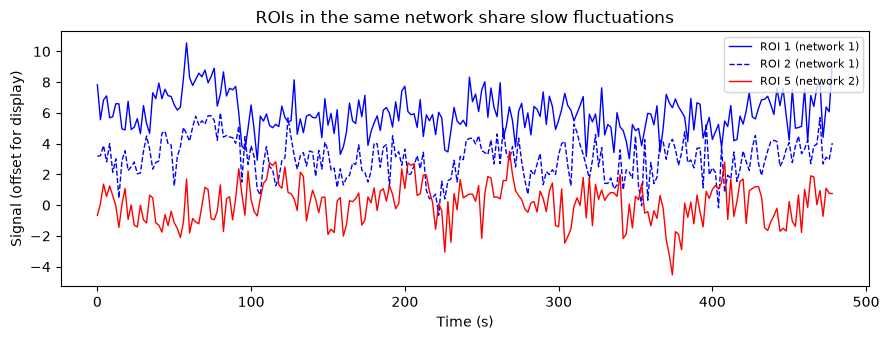

In [2]:
n_t, n_net, roi_per = 240, 3, 4     # n_t = volumes (8 min at TR = 2 s); n_net = networks; roi_per = ROIs per network
n_roi = n_net * roi_per             # total ROIs (12)
TR = 2.0                            # repetition time (s)
t = np.arange(n_t) * TR

def zscore(x):
    return (x - x.mean(axis=0)) / x.std(axis=0)

# One slow latent signal per network
latent = rng.standard_normal((n_t, n_net))
latent = zscore(uniform_filter1d(latent, size=15, axis=0))   # smooth over 15 volumes -> slow fluctuations

net_assign = np.repeat(np.arange(n_net), roi_per)   # network label per ROI
Y = 0.8 * np.repeat(latent, roi_per, axis=1) + rng.standard_normal((n_t, n_roi))   # 0.8 = network-signal strength vs. unit noise

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t, Y[:, 0] + 6, "b-",  lw=1, label="ROI 1 (network 1)")
ax.plot(t, Y[:, 1] + 3, "b--", lw=1, label="ROI 2 (network 1)")
ax.plot(t, Y[:, 4],     "r-",  lw=1, label="ROI 5 (network 2)")
ax.set(xlabel="Time (s)", ylabel="Signal (offset for display)",
       title="ROIs in the same network share slow fluctuations")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()

The two network-1 ROIs (blue) ride the same slow waves; the network-2 ROI (red) follows a different latent signal.

## 2. The parcellated functional connectivity matrix

Correlating every ROI with every other ROI gives the node-by-node **FC matrix** — a miniature functional connectome. Because our ROIs are ordered by network, the community structure appears as bright blocks along the diagonal, just like the network-sorted connectomes in Figure 30.3 of the book.

Mean within-network r:  0.400
Mean between-network r: 0.019


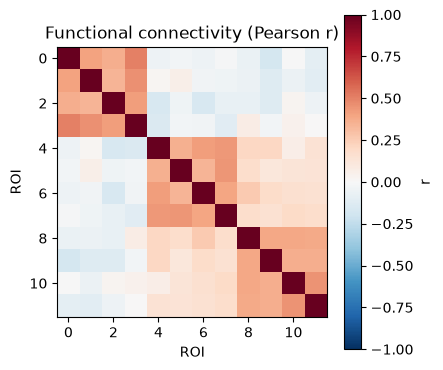

In [3]:
R_true = np.corrcoef(Y.T)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(R_true, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set(title="Functional connectivity (Pearson r)", xlabel="ROI", ylabel="ROI")
fig.colorbar(im, label="r")
plt.tight_layout()

off = ~np.eye(n_roi, dtype=bool)
within = (net_assign[:, None] == net_assign[None, :])
print(f"Mean within-network r:  {R_true[within & off].mean():.3f}")
print(f"Mean between-network r: {R_true[~within].mean():.3f}")

Within-network correlations are strong; between-network correlations hover near zero, as designed. Keep these two numbers in mind — they are the ground truth we will try to recover after contaminating the data in Section 5.

## 3. A seed correlation map

**Seed-based connectivity** correlates one region's time series with every voxel in the brain (Figure 30.2 in the book). We simulate a 48 × 48 "slice" of voxels: three circular blobs are assigned to our three networks, and background voxels contain only noise. The seed is the latent signal of network 1 — as if we had averaged the voxels of a seed ROI. Voxels in network-1 blobs should light up.

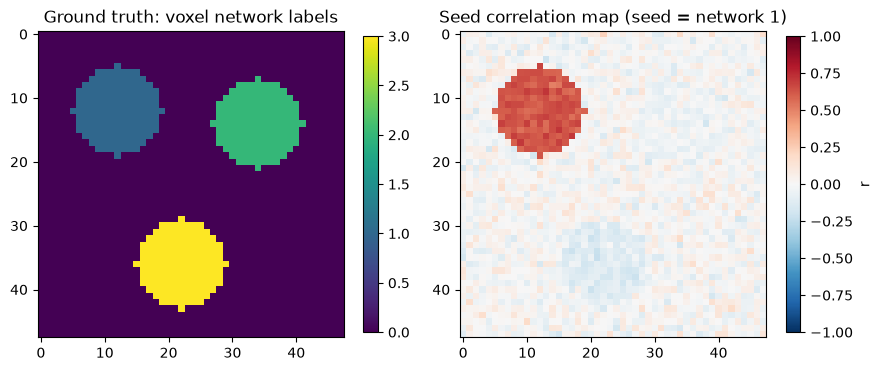

In [4]:
nx = 48                                         # grid size: nx-by-nx voxel "slice"
xx, yy = np.meshgrid(np.arange(nx), np.arange(nx))
centers = [(12, 12), (34, 14), (22, 36)]        # one blob center per network
vox_net = np.zeros((nx, nx), dtype=int)         # 0 = background
for k, (cx, cy) in enumerate(centers, start=1):
    vox_net[(xx - cx) ** 2 + (yy - cy) ** 2 <= 7 ** 2] = k   # blob radius = 7 voxels

vox_ts = rng.standard_normal((n_t, nx * nx))    # voxel-specific noise
for k in range(1, n_net + 1):
    idx = np.flatnonzero(vox_net.ravel() == k)
    vox_ts[:, idx] += 0.8 * latent[:, [k - 1]]  # 0.8 = network-signal strength vs. unit noise

seed = latent[:, 0]                             # seed time series (network 1)
seed_z = (seed - seed.mean()) / seed.std()
vox_z = zscore(vox_ts)
seed_map = (vox_z * seed_z[:, None]).mean(axis=0).reshape(nx, nx)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(vox_net, cmap="viridis")
axes[0].set(title="Ground truth: voxel network labels")
fig.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].imshow(seed_map, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set(title="Seed correlation map (seed = network 1)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="r")
plt.tight_layout()

Only the blob that shares the seed's latent signal shows strong correlations; the other networks and the background do not. In a real analysis, one such map per subject would enter a group-level statistical test.

## 4. Full vs. partial correlation: the third-variable problem

Bivariate correlation cannot distinguish a *direct* relationship from one routed through a third region. We build a chain **A → B → C**: C receives B's signal and B receives A's, but A and C have **no direct connection**. Their full correlation is nonetheless far from zero.

**Partial correlation** measures the association between two variables while controlling for the others. A convenient way to get all partial correlations at once is from the precision matrix $\Omega = \Sigma^{-1}$ — the inverse of the covariance matrix $\Sigma$ of the node time series:

::::{div}
:class: eq-tip
$$
r_{ij \cdot \text{rest}} = -\frac{\Omega_{ij}}{\sqrt{\Omega_{ii}\,\Omega_{jj}}}
$$
:::{div}
:class: eq-tip-text
r_ij·rest — partial correlation of nodes i and j controlling for all other nodes · Ω = Σ⁻¹ — precision matrix (inverse of the covariance matrix Σ) · Ω_ij — entry in row i, column j of Ω
:::
::::
:::{div}
:class: eq-where
*where* $r_{ij \cdot \text{rest}}$ *is the partial correlation between nodes* $i$ *and* $j$ *controlling for all other nodes,* $\Omega = \Sigma^{-1}$ *is the precision matrix (the inverse of the covariance matrix* $\Sigma$*), and* $\Omega_{ij}$ *is its entry in row* $i$*, column* $j$*.*
:::

In [5]:
def partial_corr(data):
    """Partial correlation matrix via the precision (inverse covariance) matrix."""
    prec = np.linalg.inv(np.cov(data.T))
    d = np.sqrt(np.diag(prec))
    P = -prec / np.outer(d, d)
    np.fill_diagonal(P, 1.0)
    return P

# Chain network: A -> B -> C, no direct A-C connection
a = zscore(uniform_filter1d(rng.standard_normal(n_t), 5))   # source region (smoothed noise)
b = zscore(0.9 * a + 0.5 * rng.standard_normal(n_t))        # 0.9 = path strength A->B; 0.5 = noise level
c = zscore(0.9 * b + 0.5 * rng.standard_normal(n_t))        # 0.9 = path strength B->C; 0.5 = noise level
ABC = np.column_stack([a, b, c])

R_full = np.corrcoef(ABC.T)
R_part = partial_corr(ABC)

print("Full correlation (A, B, C):")
print(np.round(R_full, 2))
print("\nPartial correlation (A, B, C):")
print(np.round(R_part, 2))
print(f"\nA-C edge: full r = {R_full[0, 2]:.2f} --> partial r = {R_part[0, 2]:.2f}")

Full correlation (A, B, C):
[[1.   0.88 0.8 ]
 [0.88 1.   0.88]
 [0.8  0.88 1.  ]]

Partial correlation (A, B, C):
[[1.   0.61 0.14]
 [0.61 1.   0.6 ]
 [0.14 0.6  1.  ]]

A-C edge: full r = 0.80 --> partial r = 0.14


The A–C entry drops from a substantial correlation to approximately zero once B is controlled for: partial correlation recovers the true *direct* connection structure. Two caveats from the chapter: with many nodes and limited data, partial correlations become unstable, and **regularized inverse-covariance** estimators (e.g., the graphical lasso, available in `sklearn.covariance.GraphicalLassoCV`) are preferred; and neither measure tells you the *direction* of influence — that is the province of effective connectivity models.

## 5. A shared nuisance signal inflates FC — and regression repairs it

Head motion, respiration, cardiac cycles, and scanner drift inject **common variance into time series brain-wide**. Any signal shared by two ROIs raises their correlation, whether or not it is neural. We add one slow nuisance signal to *every* ROI and compare three FC matrices: the truth, the contaminated version, and the version after nuisance regression — the core operation of connectivity preprocessing pipelines (e.g., CANlab's `canlab_connectivity_preproc`, which residualizes on motion parameters, ventricle/white-matter signals, and drift).

Mean between-network r (truth is ~0):
  true         0.019
  contaminated 0.480
  cleaned      0.021


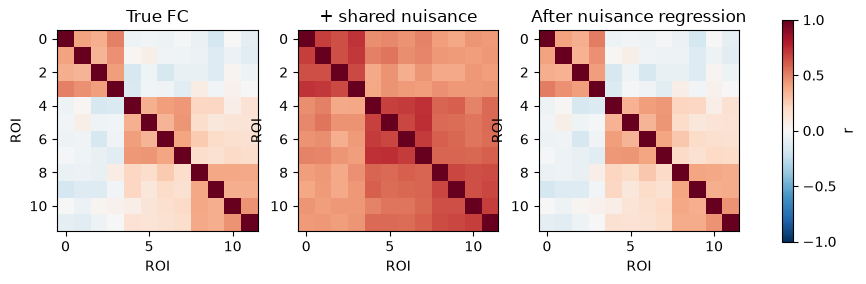

In [6]:
# Shared nuisance signal (respiration / slow motion-like), added to every ROI
g = uniform_filter1d(rng.standard_normal(n_t), 20)   # smooth over 20 volumes -> slow nuisance signal
g = (g - g.mean()) / g.std()                         # z-score the nuisance signal
Y_bad = Y + 1.2 * np.outer(g, np.ones(n_roi))        # 1.2 = artifact amplitude vs. unit noise

# Nuisance regression: residualize each ROI on [nuisance, intercept]
Xn = np.column_stack([g, np.ones(n_t)])
beta, *_ = np.linalg.lstsq(Xn, Y_bad, rcond=None)
Y_clean = Y_bad - Xn @ beta

R_bad, R_clean = np.corrcoef(Y_bad.T), np.corrcoef(Y_clean.T)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (M, title) in zip(axes, [(R_true, "True FC"),
                                 (R_bad, "+ shared nuisance"),
                                 (R_clean, "After nuisance regression")]):
    im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set(title=title, xlabel="ROI", ylabel="ROI")
fig.colorbar(im, ax=axes, shrink=0.8, label="r")

print("Mean between-network r (truth is ~0):")
print(f"  true         {R_true[~within].mean():.3f}")
print(f"  contaminated {R_bad[~within].mean():.3f}")
print(f"  cleaned      {R_clean[~within].mean():.3f}")

The contaminated matrix is inflated *everywhere* — including between networks that are truly unconnected — which is exactly how residual motion and physiological noise masquerade as "connectivity" in real data. Regressing out the nuisance signal restores estimates close to the truth.

Two practical notes. First, this only works if you can *measure or estimate* the nuisance signal (motion parameters, physiological recordings, or ventricle/white-matter time series as noise proxies). Second, regressing out the **global mean signal** removes shared artifacts too, but the global signal also contains widely distributed neural activity, and its removal mathematically induces negative correlations — the ongoing global signal regression debate.

## 6. Reliability: FC estimates stabilize with scan duration

Correlations estimated from short scans are noisy. We simulate two long independent "sessions" from the **same generative model** (identical true FC) and ask: how similar are the estimated edges across sessions as a function of scan length? The correlation between the two vectorized FC matrices is a simple reliability index — the same logic that underlies connectome fingerprinting.

   60 volumes (   2 min): edge similarity r = 0.533
  120 volumes (   4 min): edge similarity r = 0.763
  240 volumes (   8 min): edge similarity r = 0.812
  480 volumes (  16 min): edge similarity r = 0.932
 1200 volumes (  40 min): edge similarity r = 0.972


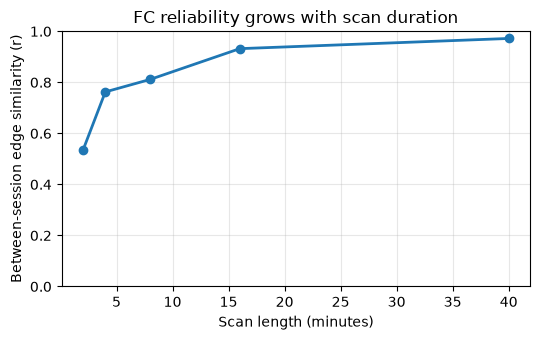

In [7]:
def simulate_session(seed, n_t_long):
    r = np.random.default_rng(seed)
    lat = r.standard_normal((n_t_long, n_net))
    lat = zscore(uniform_filter1d(lat, size=15, axis=0))
    return 0.8 * np.repeat(lat, roi_per, axis=1) + r.standard_normal((n_t_long, n_roi))

n_long = 1200                                    # 40 min at TR = 2 s
Y1, Y2 = simulate_session(101, n_long), simulate_session(202, n_long)

iu = np.triu_indices(n_roi, k=1)                 # unique edges
lengths = np.array([60, 120, 240, 480, 1200])    # scan lengths (volumes) to evaluate
reliability = []
for L in lengths:
    v1 = np.corrcoef(Y1[:L].T)[iu]
    v2 = np.corrcoef(Y2[:L].T)[iu]
    reliability.append(np.corrcoef(v1, v2)[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(lengths * TR / 60, reliability, "o-", lw=2)
ax.set(xlabel="Scan length (minutes)", ylabel="Between-session edge similarity (r)",
       title="FC reliability grows with scan duration", ylim=(0, 1))
ax.grid(alpha=0.3)
plt.tight_layout()

for L, r in zip(lengths, reliability):
    print(f"{L:>5d} volumes ({L * TR / 60:4.0f} min): edge similarity r = {r:.3f}")

Short scans yield unstable connectomes; reliability climbs steeply with duration. This is one reason connectome fingerprinting achieves ~94% identification with long, high-quality scans (Human Connectome Project), and why many groups now collect 20+ minutes of resting-state data per person.

## Wrap-up

You built the essential machinery of functional connectivity analysis and probed its two classic failure modes:

- **ROI time series → FC matrix**: within-network correlations reveal community structure
- **Seed maps**: one region's time series correlated against a whole image
- **Full vs. partial correlation**: indirect (third-variable) paths inflate bivariate correlations; partial correlation (or regularized precision estimation) recovers direct connections
- **Nuisance signals**: shared artifacts inflate FC everywhere; nuisance regression is the repair
- **Reliability**: FC estimates need substantial data to stabilize

On real data, the same steps appear as: connectivity preprocessing (nuisance regression + filtering — e.g., `canlab_connectivity_preproc` in CANlab tools, or `nilearn.maskers.NiftiLabelsMasker` with `confounds=` in Python), atlas-based ROI extraction, and `nilearn.connectome.ConnectivityMeasure` for full, partial, or tangent-space connectivity. Chapters 31–36 build outward from here: decompositions (ICA/PCA), network/graph analysis, dynamic connectivity, and effective connectivity models (SEM, DCM, Granger causality).